## Selection of appropriate k-fold Cross-validation

In [ ]:
# Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import RobustScaler, LabelEncoder

# load the dataset
df = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC']

# Preprocessing: Exclude specified columns
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Define a range of k values
k_values = [2, 5, 10, 15]

# Create a dictionary to store mean cross-validation scores for each model
mean_scores = {}

# Models with short forms
models = {
    'DT': DecisionTreeRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'RF': RandomForestRegressor(),
    'XGBoost': XGBRegressor(),
    'Bagging': BaggingRegressor()
}
# Choose 'r2' as the evaluation metric
metric = 'r2'

# Perform cross-validation for each model and each k value
for model_name, model in models.items():
    model_mean_scores = []
    for k in k_values:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train_standardized, y_train, cv=kf, scoring='r2')
        model_mean_scores.append(scores.mean())
    mean_scores[model_name] = model_mean_scores

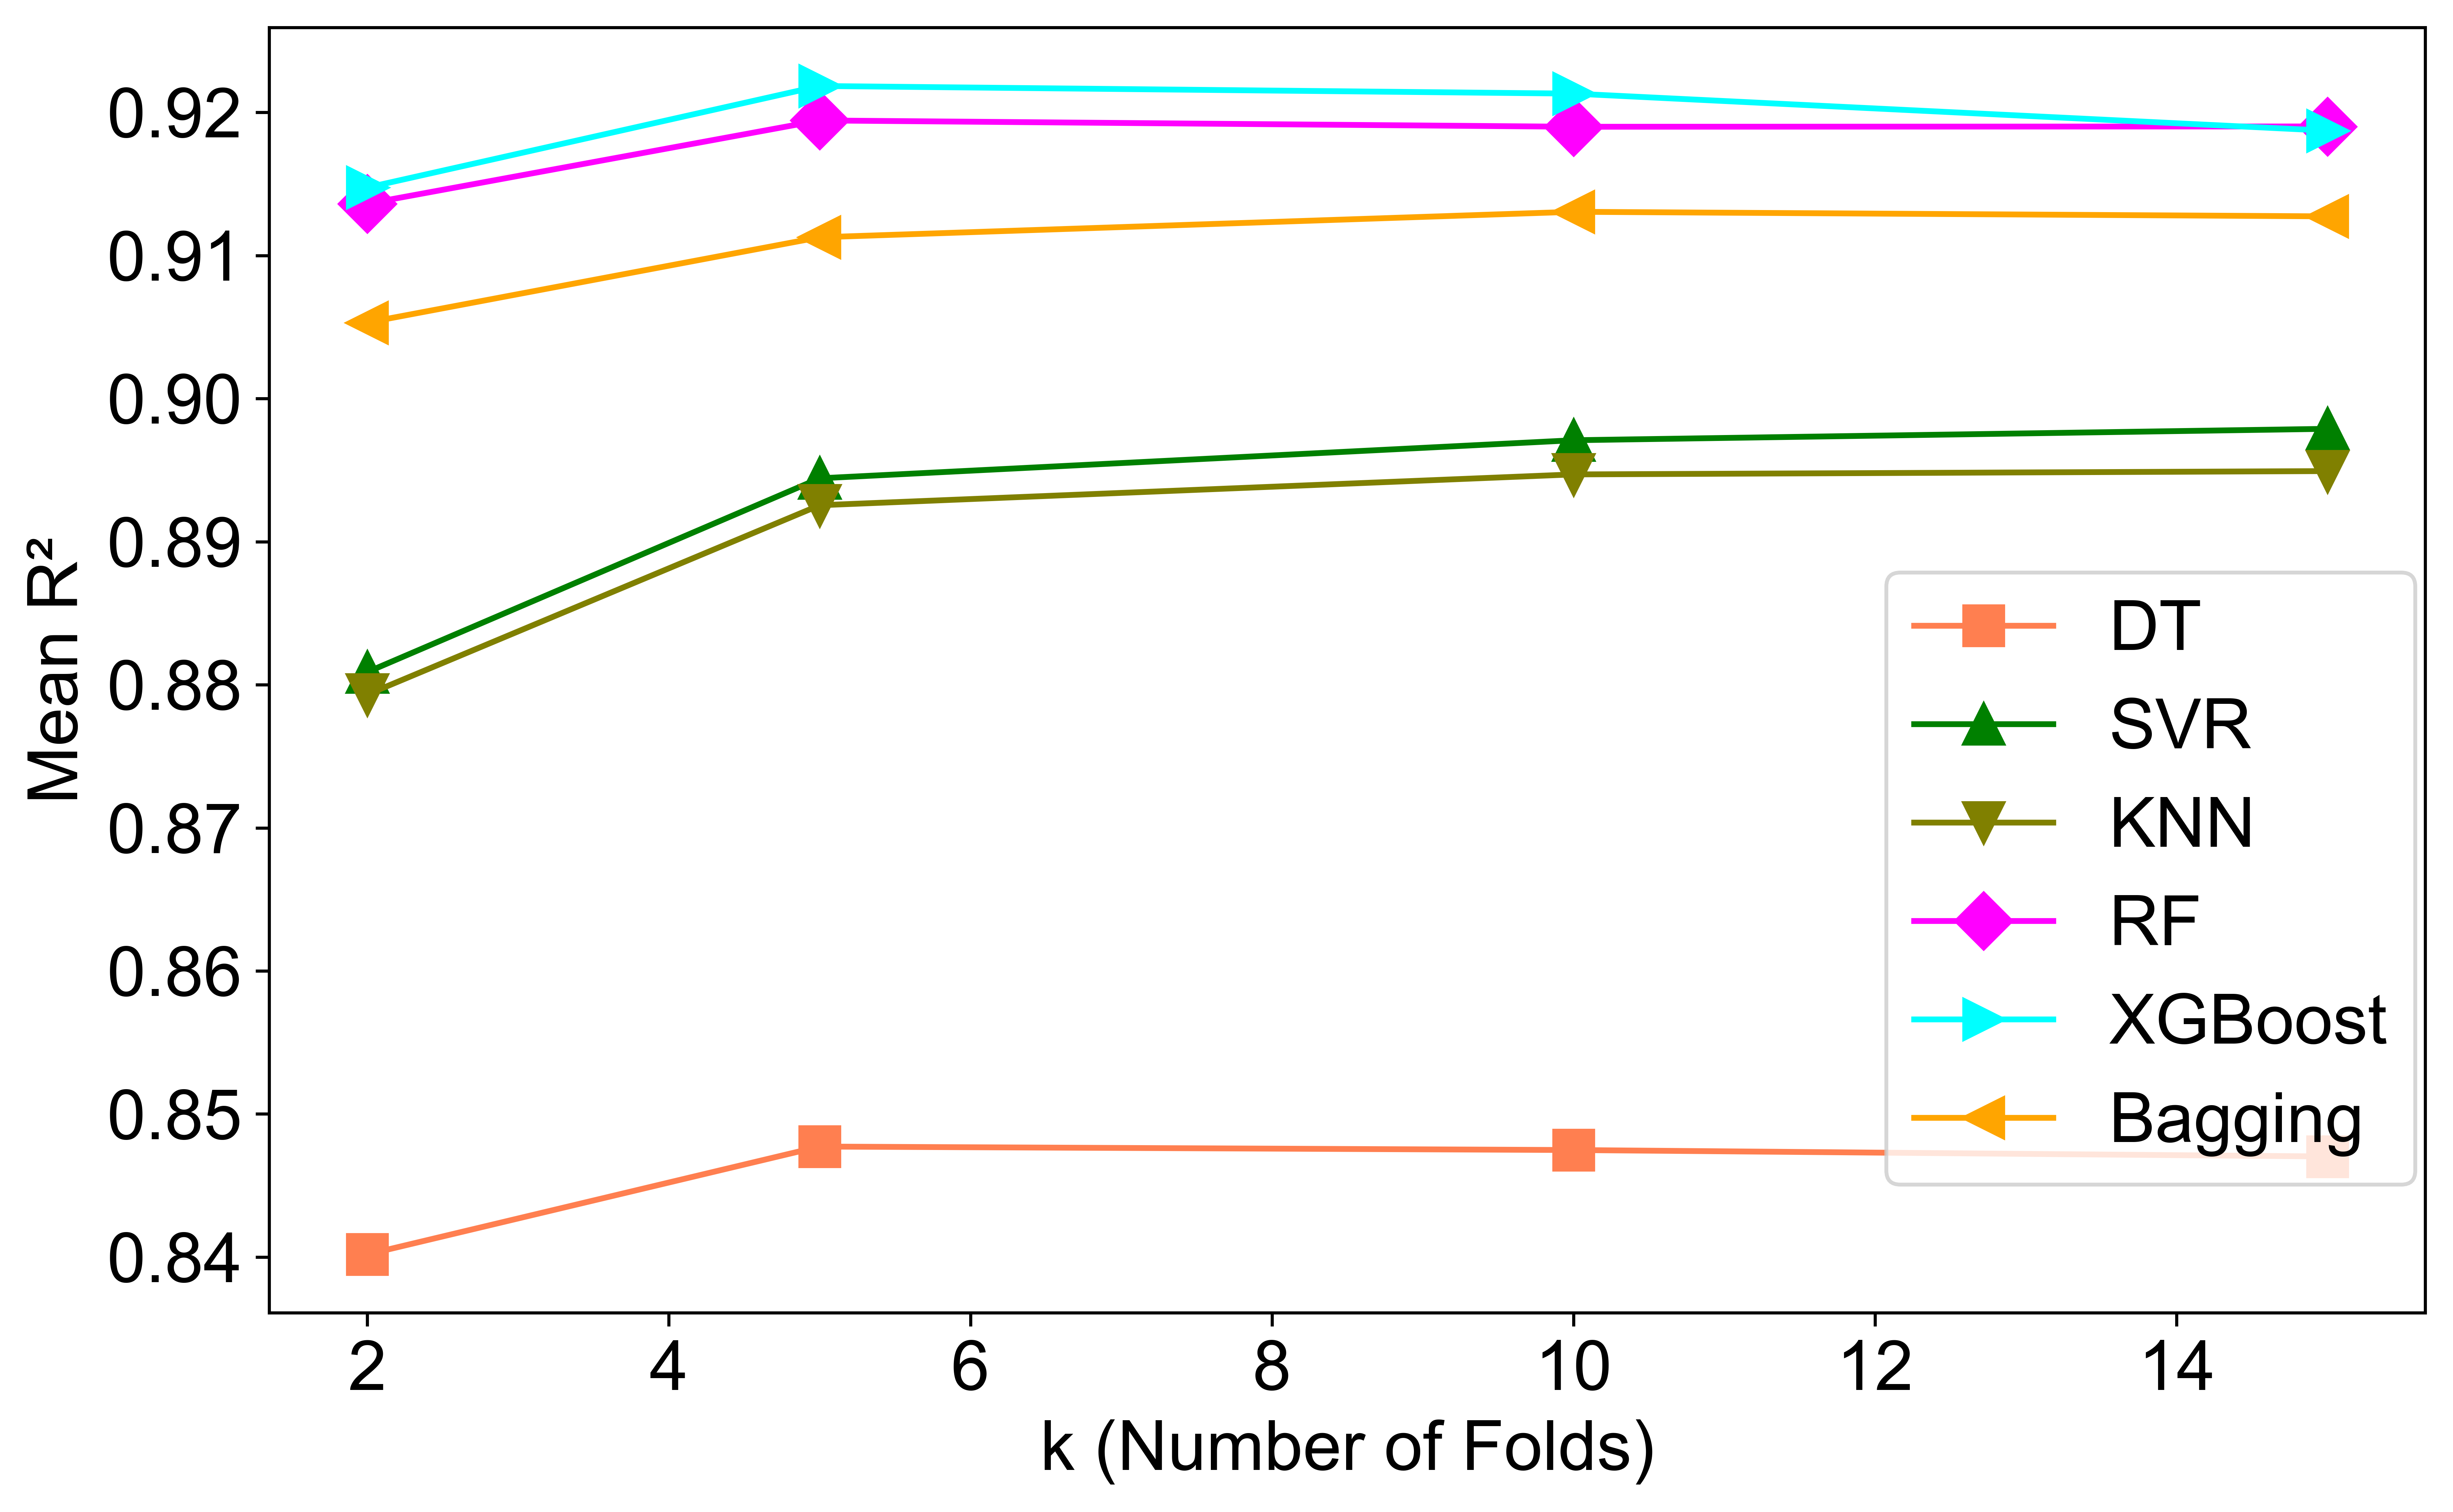

In [3]:
# Plot the results
plt.figure(figsize=(10, 6), dpi=800)
plt.rc('font', family='Arial')

# Define colors for each model
model_colors = {
    'SVR': 'green',
    'DT': 'coral',
    'RF': 'magenta',
    'KNN': 'olive',
    'XGBoost': 'cyan',
    'Bagging': 'orange'
}
# Define markers for each model
model_markers = {
    'SVR': '^',
    'DT': 's',
    'RF': 'D',
    'KNN': 'v',
    'XGBoost': '>',
    'Bagging': '<'
}


# Plot results with colors and markers
for model_name, scores in mean_scores.items():
    plt.plot(k_values, scores, marker=model_markers[model_name], markersize=10, label=model_name, color=model_colors[model_name])

plt.xlabel('k (Number of Folds)', fontsize=18)
plt.ylabel('Mean R²', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(loc=(0.75, 0.1), fontsize=18)
plt.show()
